# Creating a Filter, Edge Detection

### Import resources and display image

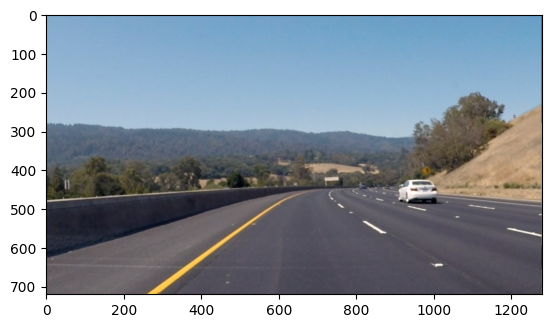

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
import numpy as np

%matplotlib inline

# Read in the image
image = mpimg.imread('images/curved_lane.jpg')

plt.imshow(image)

### Convert the image to grayscale

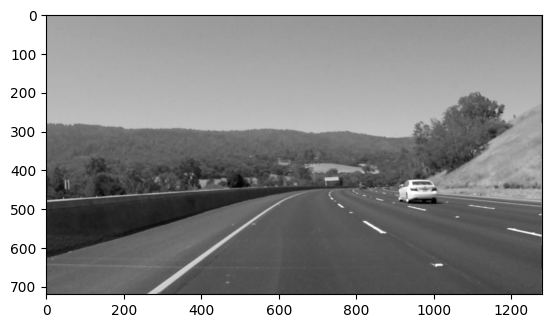

In [2]:
# Convert to grayscale for filtering
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')

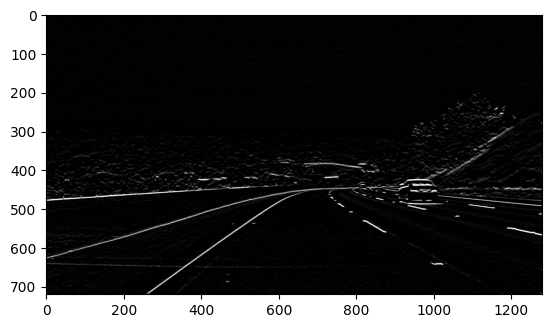

In [5]:
# 3x3 array for edge detection
sobel_y = np.array([[ -1, -2, -1], 
                   [ 0, 0, 0], 
                   [ 1, 2, 1]])

sobel_x = np.array([[ -1, -2, -1], 
                   [ 0, 0, 0], 
                   [ 1, 2, 1]]).T

filtered_image = cv2.filter2D(gray, -1, sobel_y)

plt.imshow(filtered_image, cmap='gray')

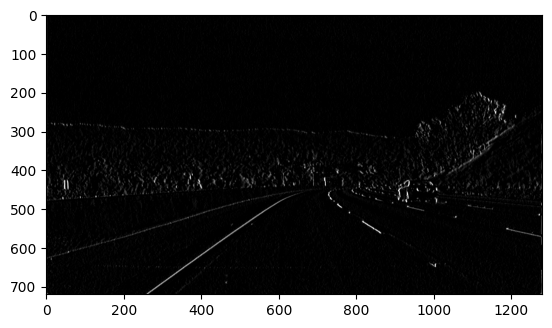

In [6]:
filtered_imagex = cv2.filter2D(gray, -1, sobel_x)

plt.imshow(filtered_imagex, cmap='gray')

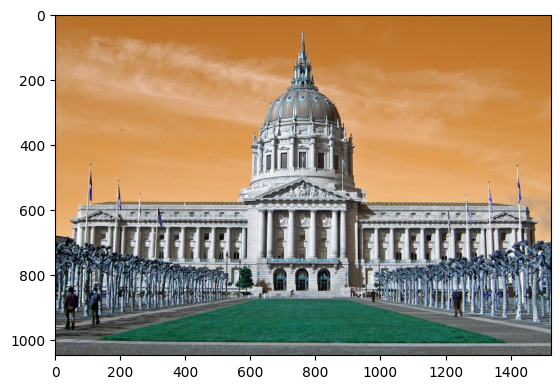

In [8]:
image = cv2.imread('images/city_hall.jpg')

plt.imshow(image)

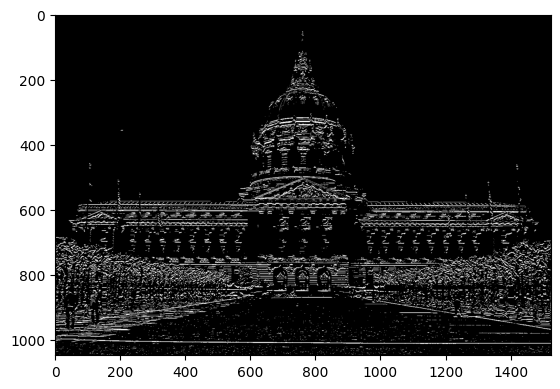

In [16]:
img_copy = np.copy(image)
img_copy = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
gray2 = cv2.cvtColor(img_copy, cv2.COLOR_RGB2GRAY)
filtered_image_2 = cv2.filter2D(gray2, -1, sobel_y)

retval, binary_image = cv2.threshold(filtered_image_2, 100, 255, cv2.THRESH_BINARY)

plt.imshow(binary_image, cmap="gray")

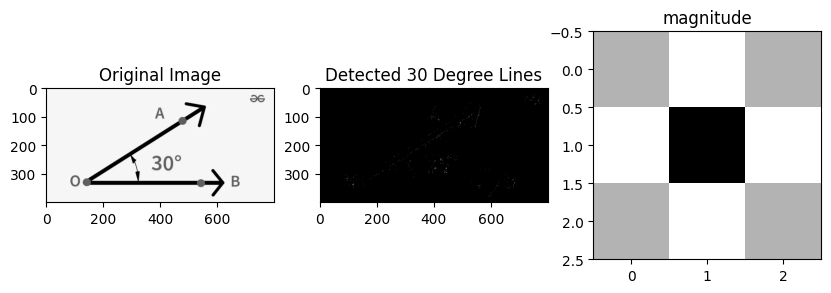

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

def detect_30_degree_lines(image_path, tolerance = 5):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Sobel Horizontal
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Sobel Vertical

    gradient_direction = np.arctan2(sobely, sobelx)

    magnitude = np.sqrt(sobel_x**2+sobel_y**2)

    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    
    magnitude = np.uint8(magnitude)

    target_angle = 30 * np.pi / 180  
    
    tolerance = tolerance * np.pi / 180

    lower_bound = target_angle - tolerance
    upper_bound = target_angle + tolerance
    mask = (gradient_direction >= lower_bound) & (gradient_direction <= upper_bound)

    detected_lines = np.zeros_like(image)
    detected_lines[mask] = image[mask]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Original Image')
    plt.subplot(1, 3, 2), plt.imshow(detected_lines, cmap='gray'), plt.title('Detected 30 Degree Lines')
    plt.subplot(1, 3, 3), plt.imshow(magnitude, cmap='gray'), plt.title('magnitude')
    plt.show()

detect_30_degree_lines('images/30-degree-angle.png')

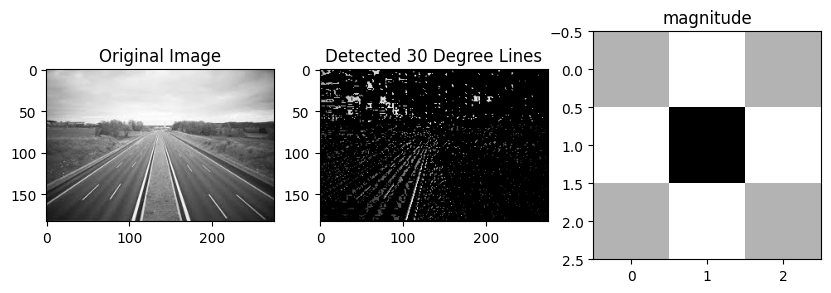

In [39]:
detect_30_degree_lines('images/lanes1.jpeg', tolerance=20)